# To do
- Find the alignment problem of 150 ms (motor?) in group 4 (experiment=2AFC_4)
- ~~Repeat all analyses per mouse (figure with a subplots)~~
- Check ILI distributions using only the first interval (between 1st and 2nd licks) instead of the mean
- Use raw distributions instead of KDE when not comparing distributions. We have **a ton** of trials, so we can afford it
- Log scale in y-axis in RT distributions to stretch around the peak
- Check if the 2 peaks in bimodal RT distributions correspond to the first interval (between 1st and 2nd licks) of the ILI. It could be due to preparatory licks (mouse start licking before the lickport is available and when the lickport does come sometimes it register the 1st lick of the train and sometimes the 2nd). If not:
    - Check split in engaged/disengaged to explain bimodality
- ~~Plot lick rate as discrete distributions (it's not possible to do 0.5 licks). As mean lick rate per ILD too for cleaner plot~~
- Check if bimodality is there in groups with
    - Delay (#4-6)
    - Fixed XYZ positions (#6)
    - No evidence levels (# 5-6)

In [1]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

from glue_sessions.glue_sessions import *
from cherry import *
from licks import *
from plotting_style import *
from my_fun.my_fun import save_notebook_files

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [15]:
# Plotting style
default_figsize = np.array(plt.rcParams['figure.figsize'])
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'

# Load behavioral data

In [4]:
experiments = [
    '2AFC_2',
    '2AFC_3',
    '2AFC_4',
    '2AFC_5',
    '2AFC_6',
]
df_behavior = glue_groups(experiments)

# Filter data

In [5]:
# Drop misses (no licks nor RT)
df_behavior = df_behavior[df_behavior.Miss == 0].reset_index(drop=True)

# Filters for groups 1-3
# df_behavior = df_behavior[df_behavior.Stage == 4].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.Motor == 4].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.StimDur == 1].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.P > 0].reset_index(drop=True)

# Filters for groups 4-5 (otherwise bump in lick rate before stimulus onset)
# df_behavior = df_behavior[df_behavior.StimDur == 1].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.Task == 'FD'].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.Delay == 0.5].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.P > 0].reset_index(drop=True)

# Filter for groups 1-4 (otherwise bump in lick rate before stimulus onset)
df_behavior = df_behavior[df_behavior.P > 0].reset_index(drop=True)

print(f'{round(len(df_behavior) / 1000)}k trials')

528k trials


# Add lick data

In [6]:
# Save old columns for comparison later
old_columns = list(df_behavior.columns)

# Add lick data to the DataFrame
df_behavior = add_lick_data(df_behavior)

# Add session half index (0 for the 1st and 1 for the 2nd)
df_behavior['SessionHalf'] = (df_behavior.Trial >= df_behavior.groupby('Session').Trial.transform('max') / 2).astype(int)
# Add absolute ILD
loc = df_behavior.columns.get_loc('ILD') + 1  # To the right of ILD column
df_behavior.insert(loc, 'absILD', df_behavior['ILD'].abs())  # Add previous stimulus side column

# Print new columns added to the DataFrame
new_columns = list(df_behavior.columns)
new_columns = [col for col in new_columns if col not in old_columns]
print(new_columns)

# df_behavior.head()

1.23% of premature lick trials (before response window)
Port1In or Port2In are already lists
['absILD', 'LicksLeft', 'LicksRight', 'nLicksLeft', 'nLicksRight', 'nLicks', 'leftILI', 'rightILI', 'ILI', 'RT', 'RT2', 'SessionHalf']


In [7]:
# Sometimes pandas doesn't recognize all nans as actual nans. Force it and remove them
df_behavior['RT'] = pd.to_numeric(df_behavior['RT'], errors='coerce')
df_behavior = df_behavior.dropna(subset=['RT']).reset_index(drop=True)
assert len(df_behavior) == len(df_behavior['RT'].dropna().values.reshape(-1, 1))

# Reaction Times (RTs)

## Between groups RT misalignment

There is something off with the RTs in 2AFC_4-6 experiments, that they are shifted by ca. 150 ms. It's probably due to the dramatic redesign of the finite state machine (FSM) done from group 4. The 150 ms matches the time the motor needs to travel, so it is likely related to that. The hypothesis is that the difference is an artifact in the task code when we changed from the stages version of the task (inherited from Tiffany) to the redesigned version of the task (when Daniela was here).

The RT are measured as the length in time in the state ResponseWindow.

In [ ]:
# Unpack groups into different DataFrames
df2 = df_behavior[df_behavior.Experiment == '2AFC_2'].copy()
df3 = df_behavior[df_behavior.Experiment == '2AFC_3'].copy()
df4 = df_behavior[df_behavior.Experiment == '2AFC_4'].copy()
df5 = df_behavior[df_behavior.Experiment == '2AFC_5'].copy()
df6 = df_behavior[df_behavior.Experiment == '2AFC_6'].copy()

In [ ]:
# Plot RTs distributions across groups
plot_licks_dist(df2, var='RT', density=True, color='tab:blue', label='2AFC_2')
plot_licks_dist(df3, var='RT', density=True, color='tab:orange', label='2AFC_3')
plot_licks_dist(df4, var='RT', density=True, color='tab:green', label='2AFC_4')
plot_licks_dist(df5, var='RT', density=True, color='tab:red', label='2AFC_5')
plot_licks_dist(df6, var='RT', density=True, color='tab:purple', label='2AFC_6')

There are clearly 2 clusters of RTs, one cluster of groups #2-3 with a median RT of around 150 ms and another cluster of RTs of groups #4-6 with a median of around 300 ms. That matches the deep task code change between groups 3 and 4, where we completely redesigned the finite state machine (FSM). Let's quantify that difference for later debugging.

In [ ]:
experiment2 = df2.Experiment.unique()[0]
experiment3 = df3.Experiment.unique()[0]
experiment4 = df4.Experiment.unique()[0]
experiment5 = df5.Experiment.unique()[0]
experiment6 = df6.Experiment.unique()[0]

median_RT2 = df2.RT.median()
median_RT3 = df3.RT.median()
median_RT4 = df4.RT.median()
median_RT5 = df5.RT.median()
median_RT6 = df6.RT.median()

medianRT2_3 = np.mean((median_RT2, median_RT3))
medianRT4_6 = np.mean((median_RT4, median_RT5, median_RT6))
artifact_RT = medianRT4_6 - medianRT2_3

print(f'Median RT of Group {experiment2}: {median_RT2}')
print(f'Median RT of Group {experiment3}: {median_RT3}')
print(f'Median RT of Group {experiment4}: {median_RT4}')
print(f'Median RT of Group {experiment5}: {median_RT5}')
print(f'Median RT of Group {experiment6}: {median_RT6}')
print('\n')
print(f'Median RT of Groups 2-3 {medianRT2_3}')
print(f'Median RT of Groups 4-6 {medianRT4_6}')
print('\n')
print(f'Difference in median RT between the 2 clusters is: {artifact_RT}')

In [ ]:
# Substract the artifact from groups #4-6
df4.RT = df4.RT - artifact_RT
df5.RT = df5.RT - artifact_RT
df6.RT = df6.RT - artifact_RT

In [ ]:
# Replot RTs distributions across groups
plot_licks_dist(df2, var='RT', density=True, color='tab:blue', label='2AFC_2')
plot_licks_dist(df3, var='RT', density=True, color='tab:orange', label='2AFC_3')
plot_licks_dist(df4, var='RT', density=True, color='tab:green', label='2AFC_4')
plot_licks_dist(df5, var='RT', density=True, color='tab:red', label='2AFC_5')
plot_licks_dist(df6, var='RT', density=True, color='tab:purple', label='2AFC_6')

These are the code blocks causing the mismatch:

stage_training_v2:
sma.add_state(
    state_name='MotorIn',
    state_timer=0.15,
    state_change_conditions={'Tup': AW},
    output_actions=[(Bpod.OutputChannels.Serial1, 2), (Bpod.OutputChannels.BNC1, 0)])

stage_training_v4:
sma.add_state(
    state_name='ResponseWindow',  # Example's state is 'WaitForResponse'
    state_timer=int(conf.VAR_RESP_WIN),
    state_change_conditions=lick,
    output_actions=[motor_in, display_response])  # Display "Response" in video

In [8]:
# There is a difference in the RTs between groups 2-3 and 4-6. Groups 2-3 values are pure RTs, as there was a MotorIn state that lasted 150 ms, the time that the motor needed to travel forward, so that when the ResponseWindow opened the lickport was already available. Groups 4-6 values contain those the time the motor needed to travel, as the motor in movement was the output action of the ReponseWindow state. This matches the 150 ms difference between the RTs clusters of groups 2-3 and 4-6. This is caused by the finite state machine (FSM) changes from group 4 onwards.

if '2AFC_4' in experiments:
    df_behavior.loc[df_behavior.Experiment == '2AFC_4', 'RT'] -= 0.15
if '2AFC_5' in experiments:
    df_behavior.loc[df_behavior.Experiment == '2AFC_5', 'RT'] -= 0.15
if '2AFC_6' in experiments:
    df_behavior.loc[df_behavior.Experiment == '2AFC_6', 'RT'] -= 0.15

## Refilter data
Remove groups (5-6) and subjects not used for subsequent analyses

In [9]:
df_behavior.Subject = df_behavior.Subject.astype(int).astype(str).str.zfill(3)  # 0 padd subjects for consistent XXX ID and ensure string format
animals = main(experiments)  # Cherry pick
all_animals = [a for expt in ['2AFC_2', '2AFC_3', '2AFC_4'] for a in animals[expt]]  # Unpack cherries
print(f'{len(all_animals)} mice: {all_animals}')
df_behavior = df_behavior[df_behavior['Subject'].isin(all_animals)].reset_index(drop=True)  # Filter cherries

Cherry picking for experiment: 2AFC_2
Number of responded trials in data collection (with evidences):
325.0: 7279 trials
326.0: 2211 trials
327.0: 9386 trials
328.0: 0 trials
329.0: 11541 trials
330.0: 4658 trials
331.0: 0 trials
332.0: 27879 trials
333.0: 25533 trials
334.0: 102 trials
335.0: 12712 trials
337.0: 20602 trials


Subjects left behind (never learnt):
328.0: 0 trials
331.0: 0 trials
334.0: 102 trials


Bad subjects (based on lapses): []

Good subjects:
325: 0.32 lapses
326: 0.65 lapses
327: 0.17 lapses
329: 0.34 lapses
330: 0.35 lapses
332: 0.36 lapses
333: 0.14 lapses
335: 0.22 lapses
337: 0.35 lapses


Cherry picking for experiment: 2AFC_3
Number of responded trials in data collection (with evidences):
387.0: 0 trials
395.0: 0 trials
398.0: 0 trials
419.0: 10403 trials
420.0: 20117 trials
422.0: 21061 trials
501.0: 0 trials
614.0: 0 trials
615.0: 0 trials
616.0: 14090 trials
617.0: 1728 trials
618.0: 0 trials
619.0: 7257 trials
620.0: 949 trials
623.0: 13642 trials
625.0

## Distributions

### All trials

In [ ]:
plot_licks_dist(df_behavior, var='RT', density=True)

This is the rawest representation of RT data. It includes all trials from all mice. There is a bimodal distribution of RTs across all mice. The overall distribution has a shoulder-like second peak (lower) after the first one. It is maybe due to the presence of two different strategies in the task: one that involves a fast response and another that involves a slower response. Let's rule out other parsimonious hypotheses first (more likely, easier and faster to check).

First, let's check if this bimodality exist in single subjects, or if in turn it is an averaging artifact.

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_dist, var='RT', density=True)
plt.suptitle('RT')
plt.tight_layout()

The bimodality is indeed present in quite some single subjects.

One hypothesis is that the difference evidence levels (ILDs) drives different RTs. To examine this, we can plot a RT distribution per ILD level. To visually compare the distributions, a Kernel Desnity Estimation (KDE) plot is preferred.

#### Gaussian Mixture fit

In [ ]:
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

# Get your data as a 1D array (drop NaNs if needed)
rt = df_behavior.RT.dropna().values.reshape(-1, 1)

# Fit a 2-component Gaussian mixture
gm = GaussianMixture(n_components=4)
gm.fit(rt)

# Plot the RT distribution
plot_licks_dist(df_behavior, var='RT', density=True)

# Plot the GMM fit
x = np.linspace(rt.min(), rt.max(), 1000).reshape(-1, 1)
logprob = gm.score_samples(x)
pdf = np.exp(logprob)
plt.plot(x, pdf, color='tab:gray', lw=3, label='GM')

# Get predicted component for each sample
labels = gm.predict(rt)

# Flatten means and covariances
gm_means = gm.means_.flatten()
gm_covariances = gm.covariances_.flatten()
gm_weights = gm.weights_.flatten()

# Sort component indices by mean RT
sorted_idx = np.argsort(gm_means)

# Create a mapping from old component label -> new label by order of means
label_map = {old_label: new_label for new_label, old_label in enumerate(sorted_idx)}

# Relabel the predicted labels accordingly
sorted_labels = np.array([label_map[l] for l in labels])

# Add labels to df
df_behavior['RTlabelsGM'] = sorted_labels

# Plot the components in order with new labels
for i in range(len(sorted_idx)):

    orig_label = sorted_idx[i]
    mean = gm_means[orig_label]
    std = np.sqrt(gm_covariances[orig_label])
    weight = gm_weights[orig_label]

    # sns.kdeplot(rt[sorted_labels == i].squeeze(), ls=ls, label=i)
    component_pdf = weight * norm.pdf(x, loc=mean, scale=std)
    ls = '--' if i in [2, 3] else '-'
    plt.plot(x, component_pdf, ls=ls, label=i)

    print(f'Component {i}: mean={mean:.2f} s, std={std:.2f} s, weight={weight:.2f}')

plt.xlabel('RT')
plt.ylabel('Density')
plt.title('Gaussian Mixture Fit')
plt.legend(frameon=False, title='Component')
sns.despine()

##### Plot RT distributions grouped by component

In [ ]:
plt.figure(constrained_layout=True)
for i in range(len(df_behavior.RTlabelsGM.unique())):
    sns.kdeplot(df_behavior[df_behavior.RTlabelsGM==i].RT, label=i)
plt.title('RT distribution by GM component')
plt.legend(frameon=False, title='Component')
sns.despine()

##### Screening of variables to explain the difference between the first 2 components (0 and 1)

In [ ]:
columns = df_behavior.columns
print(columns)

regressors = ['Trial', 'Side', 'RepTrial', 'Hit', 'AfterHit', 'Choice', 'RepChoice',
              'ILD', 'ILDRep', 'P', 'nLicksLeft', 'nLicksRight', 'absILD', 'SessionHalf']

# Keep only rows where component is 0 or 1
X = df_behavior[df_behavior.RTlabelsGM.isin([0, 1])].copy()
y = X.RTlabelsGM
X = X[regressors]

In [ ]:
from scipy.stats import ttest_ind

results = []

for col in X.columns:
    # For numeric vars -> t-test
    group0 = X[y == 0][col].dropna()
    group1 = X[y == 1][col].dropna()
    stat, pval = ttest_ind(group0, group1, equal_var=False)
    diff = group0.mean() - group1.mean()
    results.append((col, 'numeric', diff, pval))

# Make results table
df_results = pd.DataFrame(results, columns=['Variable', 'Type', 'MeanDiff', 'pval'])
df_results['pval_adj'] = df_results['pval'] * len(df_results)  # Bonferroni correction
df_results = df_results.sort_values('pval')

print(df_results)

#### Means

In [ ]:
bin_size = 0.01

In [ ]:
# Example subject
figsize = fig_size(n_cols=2)
plot_mean_RT(df_behavior[df_behavior.Subject=='333'], bin_size=bin_size, figsize=figsize)

In [ ]:
# Mean all mice
figsize = fig_size(n_cols=2)
plot_mean_RT(df_behavior, bin_size=bin_size, figsize=figsize)

In [ ]:
# Mean per group
figsize = fig_size(n_cols=3)
plot_mean_RT(df_behavior[df_behavior.Experiment=='2AFC_2'],bin_size=bin_size, figsize=figsize)
plot_mean_RT(df_behavior[df_behavior.Experiment=='2AFC_3'],bin_size=bin_size, figsize=figsize)
plot_mean_RT(df_behavior[df_behavior.Experiment=='2AFC_4'],bin_size=bin_size, figsize=figsize)

In [ ]:
# Example subject
plot_mean_RT(df_behavior[df_behavior.Subject=='333'], figsize=figsize)

### Splits

#### ILD

In [ ]:
plot_ild_dist(df_behavior, var='RT')

Too many lines can make on top of each other make it hard to disentangle the ILD impact on RT, so we can plot the RT distribution for each ILD level separately.

In [ ]:
# Collapse the signed ILD levels to absolute values for cleaner visualization
abs_ilds = sorted(df_behavior.absILD.unique().astype(int))

# Plot the RT distribution for each absolute ILD level
fig, axes = plt.subplots(1, len(abs_ilds), figsize=(default_figsize[0]/2*len(abs_ilds), default_figsize[0]/2))
for ax, ild in zip(axes, abs_ilds):
    df_ild = df_behavior[df_behavior.absILD == ild]
    sns.kdeplot(df_ild.RT, color='k', ax=ax)
    ax.set_title(f'|ILD| = {ild}')
    sns.despine(ax=ax)
    plt.xlim(0, 0.5)

plt.tight_layout()

Although the bimodality is present in all ILD levels, the second peak is more pronounced for lower ILD levels. This suggests that the bimodality is modulated by evidence.

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_ild_dist, format='A3', var='RT', insets=True)
plt.suptitle('RT')
plt.tight_layout()

In [ ]:
plt.figure(figsize=default_figsize/2, constrained_layout=True)
plot_ild_dist_mean(df_behavior, var='RT')

The ILD alone does not seem to explain the **existence** of bimodality in the RT distribution, as the bimodality is present across all ILD levels (for subjects that did show bimodality in their RTs).

Nevertheless, zooming in the peak of the distribution (0.1-0.2 s, first inset), we can see that the RTs are faster for lower ILD levels, which is expected as the evidence is more certain. What is surprising is for this modulation to show up despite the fact that mice were head-fixed and the stimulus was fixed duration. In addition, zooming in the second peak of the distribution (0.15-0.2 s, second inset), we can see that the second peak is more pronounced for lower ILD levels, suggesting that the bimodality is actually modulated by ILD level.

Another hypothesis is that the bimodality is driven by differences in behavioral variables such as outcome, previous outcome, choice, previous choice, repeat trial, stimulus, or session half. To examine this, we can plot a RT distribution per behavioral variable split in 2 conditions.

#### Outcome

In [ ]:
plot_licks_split(df_behavior, var='RT', split='outcome', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='RT', split='outcome', kind='kde')
plt.suptitle('RT')
plt.tight_layout()

#### Previous outcome

In [ ]:
plot_licks_split(df_behavior, var='RT', split='prev_out', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='RT', split='prev_out', kind='kde')
plt.suptitle('RT')
plt.tight_layout()

#### Choice

In [ ]:
plot_licks_split(df_behavior, var='RT', split='choice', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='RT', split='choice', kind='kde')
plt.suptitle('RT')
plt.tight_layout()

#### Repeat choice

In [ ]:
plot_licks_split(df_behavior, var='RT', split='rep_choice', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='RT', split='rep_choice', kind='kde')
plt.suptitle('RT')
plt.tight_layout()

#### Repeat trial
Trials in which the stimulus (rewarded) side coincides with the previous choice

In [ ]:
plot_licks_split(df_behavior, var='RT', split='rep_trial', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='RT', split='rep_trial', kind='kde')
plt.suptitle('RT')
plt.tight_layout()

#### Stimulus

In [ ]:
plot_licks_split(df_behavior, var='RT', split='stim', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='RT', split='stim', kind='kde')
plt.suptitle('RT')
plt.tight_layout()

This bimodality can not be explained by differences in behavioral variables such as outcome, choice, stimulus, repeat, or previous outcome.

#### 1st vs 2nd session half

In [ ]:
plot_licks_split(df_behavior, var='RT', split='half', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='RT', split='half', kind='kde')
plt.suptitle('RT')
plt.tight_layout()

The bimodality is present in both halves of the session, suggesting that it is not driven by a change in the internal state of the animal. The RT distribution is similar in both halves of the session, with a slight shift towards slower RTs in the second half.

Another possibility is that the bimodality just results from the individual variability in the RTs of each subject. To examine this, we can plot the RT distribution for each subject separately. If the bimodality is driven by individual variability, we would expect to see a unimodal distribution in each subject.

#### Hidden Markov Model (HMM)

Another possibility is that the bimodality reflects the a change in the internal state of the animal (e.g. motivation, reduced by satiation as time passes) that is not captured by the behavioral variables. To examine this, we can split the data of each session into first and second half and plot the RT distribution for each half. If the bimodality is driven by a change in the internal state of the animal, we would expect to see a difference in the RT distribution between the first and second half of the session.

## Chronometric Curves

### All trials

In [ ]:
plot_chrono_curve(df_behavior, absolute=True)

### Splits

#### Outcome

In [ ]:
plot_chrono_curve_split(df_behavior, split='outcome', absolute=False)

#### Choice

In [ ]:
plot_chrono_curve_split(df_behavior, split='choice', absolute=False)

#### Stimulus

In [ ]:
plot_chrono_curve_split(df_behavior, split='stim', absolute=True)

#### Repeat

In [ ]:
plot_chrono_curve_split(df_behavior, split='repeat', absolute=False)

#### Previous outcome

In [ ]:
plot_chrono_curve_split(df_behavior, split='prev_out', absolute=False)

In [ ]:
# # Plot licks PSTH
# bins, left_psth = compute_psth(licks_left, time_win=[-1, 3], bin_size=0.1)
# bins, right_psth = compute_psth(licks_right, time_win=[-1, 3], bin_size=0.1)
# bins = bins[:-1]  # Remove the last bin edge to match the histogram length
# plot_licks_psth(bins, licks_left, licks_right)

## RTs GLM

In [75]:
subjects = df_behavior.Subject.unique()
# subjects = df_behavior[df_behavior.Experiment == '2AFC_5'].Subject.unique()

# Prepare containers
all_fe = []
all_pvals = []

for subj in subjects:

    df_subj = df_behavior[df_behavior.Subject == subj].copy()
    print(f'Fitting model for subject {subj} ({len(df_subj)})...')

    # Drop misses
    df_subj = df_subj[df_subj.Miss == 0]
    df_subj.reset_index(drop=True, inplace=True)

    # Normalize absILD
    df_subj['absILD'] = df_subj['absILD'] / df_subj['absILD'].max()

    # Add normalized trial index per session
    df_subj['NormTrial'] = df_subj.groupby('Session')['Trial'].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()))
    df_subj['NormTrial2'] = df_subj['NormTrial'] ** 2  # Squared term
    df_subj['NormTrial'] = df_subj['NormTrial'].astype(float)
    df_subj['NormTrial2'] = df_subj['NormTrial2'].astype(float)

    df_subj['SessionIndex'] = pd.Categorical(df_subj['Session']).codes

    # Define formula
    formula = 'RT ~ Choice + Hit + AfterHit + absILD + Hit:absILD + NormTrial + NormTrial2'
    # Yet to include:
    # Session index
    # p(engaged) from HMM
    # Drug for drug analyses

    # Fit GLM (Gaussian family for continuous RTs)
    # model = smf.glm(formula=formula, data=df_subj, family=sm.families.Gaussian())
    # model = smf.ols(formula=formula, data=df_subj)  # Much faster for Gaussian than GLM
    model = smf.mixedlm(formula, df_subj, groups=df_subj.SessionIndex)  # Mixed effects model with random intercepts for sessions
    result = model.fit()
    print(result.summary())

    # Store fixed-effect estimates and p-values
    # fe = result.params
    fe = result.fe_params  # For mixedlm
    fe.name = subj
    all_fe.append(fe)

    pvals = result.pvalues
    pvals.name = subj
    all_pvals.append(pvals)

# Convert to DataFrames
df_fe = pd.DataFrame(all_fe)
df_p = pd.DataFrame(all_pvals)

# print(df_fe.head())
# print(df_p.head())

Fitting model for subject 325 (7279)...


IndexError: index 7203 is out of bounds for axis 0 with size 7203

Series([], dtype: float64)
Series([], dtype: float64)
Series([], dtype: float64)


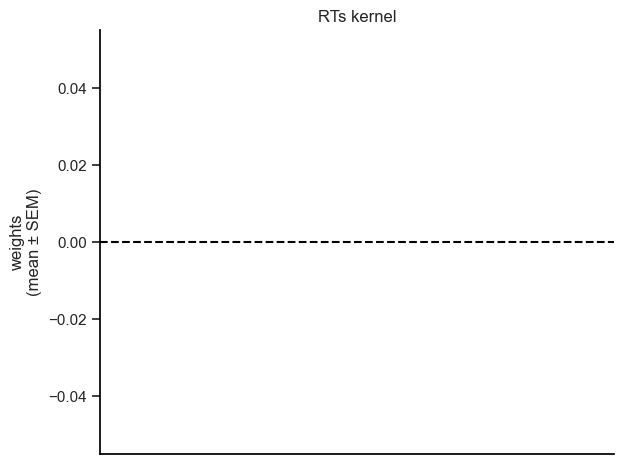

In [65]:
# Compute mean and SEM across mice
fe_mean = df_fe.mean()
fe_sem = df_fe.sem()
p_mean = df_p.mean()
print(fe_mean)
print(fe_sem)
print(p_mean)

# Highlight effects where mean p-value < 0.05
colors = ['red' if df_p[col].mean() < 0.05 else 'gray' for col in df_fe.columns]

plt.figure(constrained_layout=True)
plt.bar(range(len(fe_mean)), fe_mean, yerr=fe_sem, color=colors)
plt.xticks(range(len(fe_mean)), fe_mean.index, rotation=45, ha='right')
plt.axhline(0, color='black', linestyle='--')
plt.ylabel('weights\n(mean ± SEM)')
plt.title('RTs kernel')
plt.tight_layout()

# Lick Rate

As the number of licks depends on the time the lickport was available (motor in), which ultimately depends on the outcome (correct vs error), a time window to count the licks needs to be established. As the time to collect water in correct (rewarded) trials was always 1 s, and the timeout period following error trials varied from 2-5 s, the chosen time window to count the number of licks was 1 s. This is very convenient for the lick rate, as it is defined as

$$
\text{Lick rate} = \frac{N_{\text{licks}}}{\text{time (s)}}
$$

so that N licks = Lick Rate

## All trials

In [ ]:
plot_licks_dist(df_behavior, var='nLicks', density=True)

We can observe a first peak at 2 licks (error trials), and an sawtooth increasing second peak with max at 8 licks (correct trials). Let's split the data into several variables (like with RT) to observe how they modulate the lick rate.

In [ ]:
# plot_licks_per_subject(df_behavior, plot_func=plot_licks_dist, format='A4', var='nLicks', density=True)

As there was no water (reward) coming out of the spouts in error trials, it makes sense that the distribution of lick rate peaks at 0. It is a needed control, but from now on the analysis will focus on **correct trials only**

## Splits

### ILD

In [ ]:
plot_ild_dist(df_behavior[df_behavior.Hit==1], var='nLicks')

In [ ]:
plot_licks_per_subject(df_behavior[df_behavior.Hit==1], plot_func=plot_ild_dist, format='A4', var='nLicks')
plt.suptitle('nLicks')
plt.tight_layout()

In [ ]:
plt.figure(figsize=default_figsize/2, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Hit==1], var='nLicks')

There is a modulation in the lick rate by ILD in correct trials. The higher the ILD the higher the lick rate.

### Outcome

In [ ]:
plot_licks_split(df_behavior, var='nLicks', split='outcome', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='nLicks', split='outcome', kind='kde')
plt.suptitle('nLicks')
plt.tight_layout()

### Previous outcome

In [ ]:
plot_licks_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='prev_out', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='nLicks', split='prev_out', kind='kde')
plt.suptitle('nLicks')
plt.tight_layout()

### Choice

In [ ]:
plot_licks_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='choice', kind='kde')
plt.suptitle('nLicks')
plt.tight_layout()

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='nLicks', split='choice', kind='kde')

### Repeat choice

In [ ]:
plot_licks_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='rep_choice', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='nLicks', split='rep_choice', kind='kde')
plt.suptitle('nLicks')
plt.tight_layout()

### Repeat trial

In [ ]:
plot_licks_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='rep_trial', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='nLicks', split='rep_trial', kind='kde')
plt.suptitle('nLicks')
plt.tight_layout()

### Stimulus

In [ ]:
plot_licks_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='stim', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='nLicks', split='stim', kind='kde')
plt.suptitle('nLicks')
plt.tight_layout()

### 1st vs 2nd session half

In [ ]:
plot_licks_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='half', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='nLicks', split='half', kind='kde')
plt.suptitle('nLicks')
plt.tight_layout()

### Hidden Markov Model (HMM)

# Inter Lick Interval (ILI)

$$
\text{Lick rate (Hz)} \approx \frac{1}{\text{Mean ILI (s)}}
$$

### All trials

In [ ]:
plot_licks_dist(df_behavior, var='ILI', density=True)

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_dist, format='A4', var='ILI', density=True)
plt.suptitle('ILI')
plt.tight_layout()

### Splits

#### ILD

In [ ]:
plot_ild_dist(df_behavior[df_behavior.Hit==1], var='ILI')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_ild_dist, format='A4', var='ILI', insets=True)
plt.suptitle('ILI')
plt.tight_layout()

In [ ]:
plt.figure(figsize=default_figsize/2, constrained_layout=True)
plot_ild_dist_mean(df_behavior, var='ILI')

#### Outcome

In [ ]:
plot_licks_split(df_behavior, var='ILI', split='outcome', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='ILI', split='outcome', kind='kde')
plt.suptitle('ILI')
plt.tight_layout()

#### Previous Outcome

In [ ]:
plot_licks_split(df_behavior, var='ILI', split='prev_out', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='ILI', split='prev_out', kind='kde')
plt.suptitle('ILI')
plt.tight_layout()

#### Choice

In [ ]:
plot_licks_split(df_behavior, var='ILI', split='choice', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='ILI', split='choice', kind='kde')
plt.suptitle('ILI')
plt.tight_layout()

#### Repeat choice

In [ ]:
plot_licks_split(df_behavior, var='ILI', split='rep_choice', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='ILI', split='rep_choice', kind='kde')
plt.suptitle('ILI')
plt.tight_layout()

#### Repeat trial

In [ ]:
plot_licks_split(df_behavior, var='ILI', split='rep_trial', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='ILI', split='rep_trial', kind='kde')
plt.suptitle('ILI')
plt.tight_layout()

#### Stimulus

In [ ]:
plot_licks_split(df_behavior, var='ILI', split='stim', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='ILI', split='stim', kind='kde')
plt.suptitle('ILI')
plt.tight_layout()

#### 1st vs 2nd session half

In [ ]:
plot_licks_split(df_behavior, var='ILI', split='half', kind='kde')

In [ ]:
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, format='A4', var='ILI', split='half', kind='kde')
plt.suptitle('ILI')
plt.tight_layout()

#### Hidden Markov Model (HMM)

# Save all notebook's figures

In [ ]:
# # Whole notebook ouputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# # Export all figures
save_notebook_files('notebook.ipynb')

# Development